# 2. What the models score, and which floor they are measured against

Five models are fitted on identical folds. Two of them are never given the audio at all.

Their scores are not the interesting part. The gap between an audio model and a model that hears
nothing is the interesting part, and this notebook shows that the gap is negative and that the floor
it is measured from was in the wrong place for most of the project's life.

Run `python -m src.train.xgb --config configs/base.yaml --repeats 10`, then `src.train.cnn` for each
network, then `src.evaluate.report`.

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

# Works whether the kernel starts in the repository root or in experiments/.
sys.path.insert(0, str(Path.cwd() if (Path.cwd() / "src").is_dir() else Path.cwd().parent))

from src.config import load_config
from src.evaluate import families, tables
from src.results import config_directory, model_directory

cfg = load_config("configs/base.yaml")
REPORT = config_directory(cfg)
pd.set_option("display.width", 160)

species = next(f for f in families.discover(cfg) if f.key == families.SPECIES_FAMILY)
print("on trial:", ", ".join(species.members))
print("declared control:", species.control)

on trial: xgboost, cnn, cnn_small, logbook, probe
declared control: metadata


## 1. What is being compared

A family is a set of models plus the control they were measured against. `families.discover` reads
this off the results on disk rather than off a hardcoded list, so a model that was trained appears
here without anything being edited.

`floors` is the part worth reading. It lists every model in the family that is never shown the
recording, and there are two of them.

In [2]:
print("members :", species.members)
print("control :", species.control)
print("floors  :", species.floors)
print("classes :", species.class_names)

pd.DataFrame(
    [{"model": name, "hears the audio": name not in species.floors} for name in species.names]
)

members : ('xgboost', 'cnn', 'cnn_small', 'logbook', 'probe')
control : metadata
floors  : ('logbook', 'metadata')
classes : ('HumpbackWhale', 'SpermWhale', 'KillerWhale')


,model,hears the audio
0,xgboost,True
1,cnn,True
2,cnn_small,True
3,logbook,False
4,probe,True
5,metadata,False


## 2. What they score

Macro-F1 on held out tapes. The trees and both floors ran ten repeats of the five fold split, so
fifty estimates each. The two networks ran one split, so five. The fold count is carried in every
table below, because a five fold comparison must never be read as a fifty fold one.

`logbook` sees the recording metadata, the site, the coordinates, the noise conditions and the
collection code from notebook 01. It hears nothing, and it scores highest.

In [3]:
comparison = tables.comparison(cfg, list(species.names))
scores = tables.headline(comparison).sort_values("mean", ascending=False)
scores["splits"] = [
    len(pd.read_csv(model_directory(cfg, m) / "fold_metrics_clip.csv")) for m in scores.model
]
scores["hears the audio"] = [m not in species.floors for m in scores.model]
scores.round(4)

,model,mean,std,splits,hears the audio
3,logbook,0.9974,0.0045,50,False
5,metadata,0.8678,0.1344,50,False
0,xgboost,0.7524,0.0698,50,True
4,probe,0.7391,0.0902,50,True
1,cnn,0.7135,0.1230,5,True
2,cnn_small,0.7096,0.1418,50,True


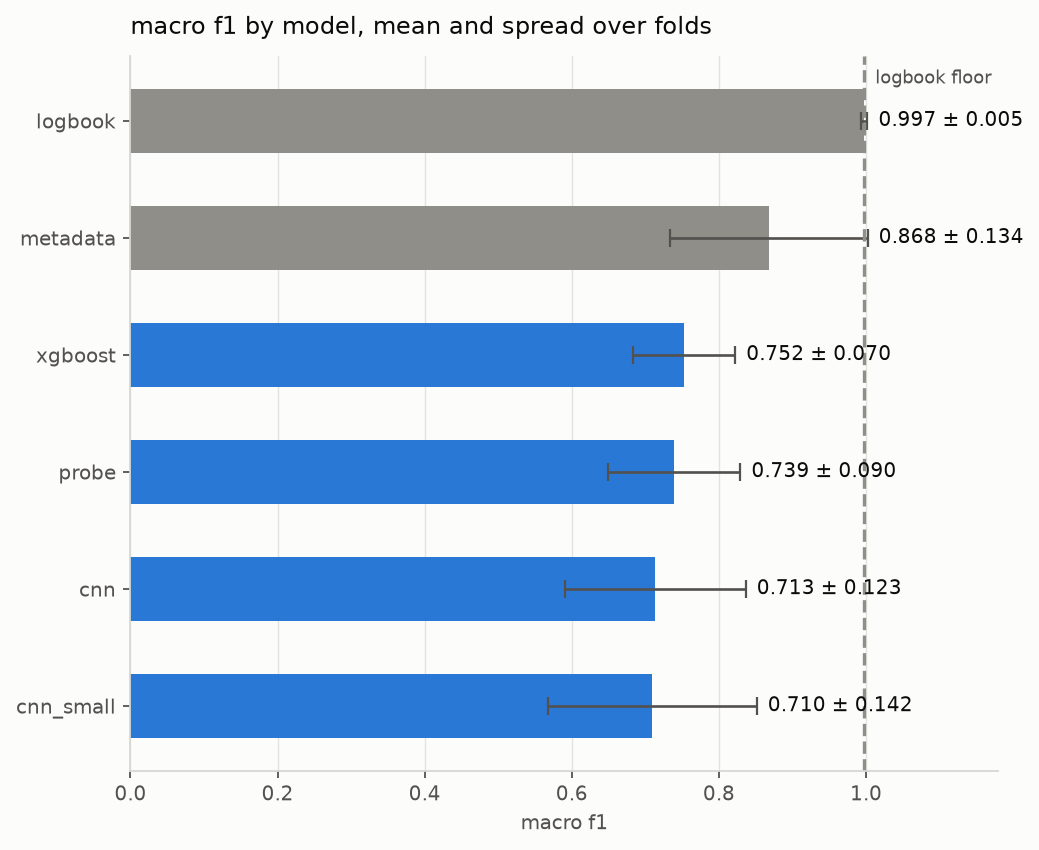

In [4]:
display(Image(filename=str(REPORT / "model_comparison.png")))

## 3. Fifty estimates, not ten folds repeated

The tree results carry a `repeat` column alongside `fold`. Ten repeats of a five fold split give
fifty rows, and repeat three fold two is a different split from repeat four fold two. Dropping the
repeat column makes the table look like five folds listed ten times.

The comparison is paired on the pair. Repeat three fold two of a model belongs with repeat three fold
two of its control, because those are the same split.

In [5]:
folds = pd.read_csv(model_directory(cfg, "xgboost") / "fold_metrics_clip.csv")
print(f"{len(folds)} rows: {folds.repeat.nunique()} repeats of {folds.fold.nunique()} folds")
folds[["repeat", "fold", "accuracy", "macro_f1"]].head(12).round(3)

50 rows: 10 repeats of 5 folds


,repeat,fold,accuracy,macro_f1
0,0,0,0.762,0.720
1,0,1,0.796,0.703
2,0,2,0.875,0.670
3,0,3,0.855,0.807
4,0,4,0.764,0.713
5,1,0,0.752,0.710
6,1,1,0.811,0.754
7,1,2,0.909,0.751
8,1,3,0.856,0.805
9,1,4,0.845,0.785


## 4. The margin over the declared control

This is the comparison the project reported for most of its life. The control sees native sample
rate, recording year, clip duration and file size.

Every audio model sits below it, and not one of the three comparisons resolves. Read the `p_value`
and `folds` columns before the margin: a difference of 0.11 over 134 recordings is a direction rather
than a result.

In [6]:
against_control = tables.family_margins(cfg, species)
against_control.round(4)

,model,mean,control,margin,low,high,p_value,agreeing,folds
3,logbook,0.9974,0.8678,0.1296,-0.0123,0.2715,0.0724,45,50
0,xgboost,0.7524,0.8678,-0.1154,-0.3101,0.0793,0.2393,38,50
4,probe,0.7391,0.8678,-0.1287,-0.3049,0.0474,0.1484,39,50
2,cnn_small,0.7096,0.8678,-0.1582,-0.4016,0.0853,0.1978,40,50
1,cnn,0.7135,0.8837,-0.1702,-0.6573,0.3169,0.3869,4,5


## 5. The control was not the floor

`strongest_floor` asks which model in the family scores highest among those that hear nothing. It is
not the declared control.

Measured against the logbook instead, the same XGBoost model that was 0.115 behind at p = 0.24 is
0.245 behind at a p value seven orders of magnitude smaller, with every one of fifty splits agreeing.
Nothing about the audio model changed. The floor moved.

Every audio model in this family clears that bar downwards, including the probe over a frozen
pretrained encoder. Four representations, four resolved negatives.

In [7]:
floor = families.strongest_floor(cfg, species)
print(f"declared control : {species.control}")
print(f"strongest floor  : {floor}")

against_floor = tables.family_margins(cfg, species, control=floor)
against_floor.round(4)

declared control : metadata
strongest floor  : logbook


,model,mean,control,margin,low,high,p_value,agreeing,folds
0,xgboost,0.7524,0.9974,-0.2450,-0.3181,-0.1720,0.0000,50,50
3,probe,0.7391,0.9974,-0.2583,-0.3525,-0.1642,0.0000,50,50
1,cnn,0.7135,0.9983,-0.2848,-0.5136,-0.0560,0.0259,5,5
2,cnn_small,0.7096,0.9974,-0.2878,-0.4358,-0.1398,0.0003,50,50


In [8]:
for frame, label in ((against_control, species.control), (against_floor, floor)):
    row = frame[frame.model == "xgboost"].iloc[0]
    print(
        f"XGBoost against {label:9s}: {row.margin:+.3f}  "
        f"p = {row.p_value:.2e}  {int(row.agreeing)} of {int(row.folds)}"
    )

XGBoost against metadata : -0.115  p = 2.39e-01  38 of 50
XGBoost against logbook  : -0.245  p = 1.66e-08  50 of 50


## 6. How wide any of these scores are

A mean across folds says nothing about how much a different draw of recordings would have changed
it. The interval below comes from resampling whole tapes with replacement, which is the unit of
independence here. Notebook 03 shows what happens if you resample clips instead.

The `tapes` column is the sample size the interval is built on.

In [9]:
intervals = tables.family_intervals(cfg, species)
intervals["width"] = (intervals.high - intervals.low).round(3)
intervals.round(4)

,model,estimate,low,high,tapes,width
0,xgboost,0.7265,0.6191,0.8387,134,0.220
1,cnn,0.7064,0.5737,0.8671,134,0.293
2,cnn_small,0.6849,0.5497,0.8535,134,0.304
3,logbook,0.9987,0.9935,1.0000,134,0.006
4,probe,0.7512,0.6313,0.8358,134,0.205
5,metadata,0.9343,0.7962,0.9832,134,0.187


## 7. Which species each model gets right

Humpback is the class the fold structure stresses hardest, because it survives on twelve recordings.
Read its column against the others.

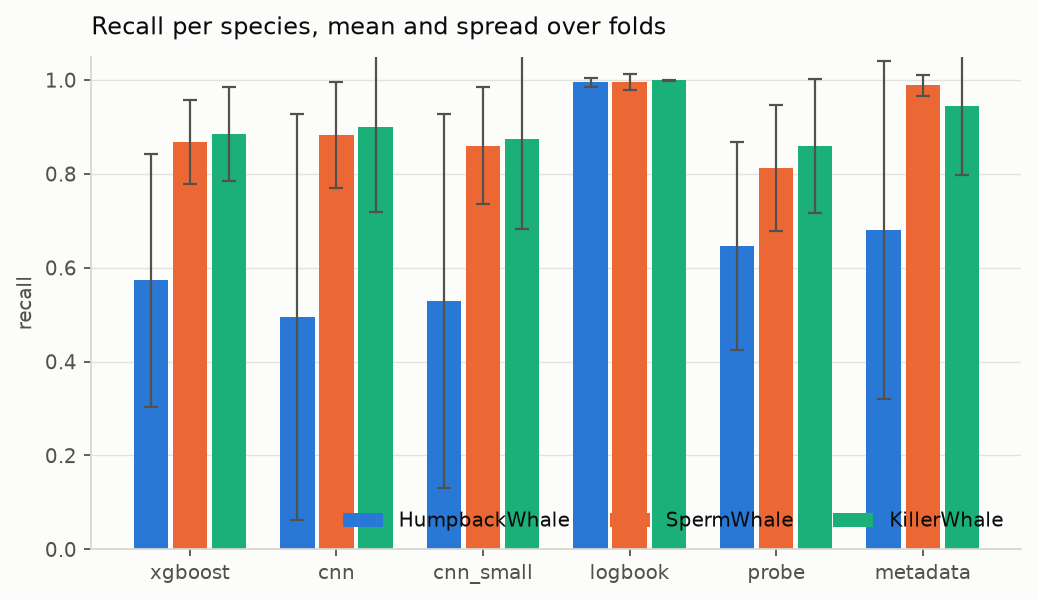

,model,HumpbackWhale,SpermWhale,KillerWhale
0,xgboost,0.573,0.869,0.885
1,cnn,0.496,0.883,0.901
2,cnn_small,0.529,0.860,0.874
3,logbook,0.995,0.996,1.000
4,probe,0.647,0.813,0.859
5,metadata,0.680,0.989,0.944


In [10]:
display(Image(filename=str(REPORT / "per_class_recall.png")))
tables.per_species_recall(comparison, list(species.class_names)).round(3)

## 8. Where the mistakes go

Each matrix is row normalised, so a row reads as recall for that species. The count printed under
each share is pooled over every split, which is fifty for the trees and five for the networks.

xgboost


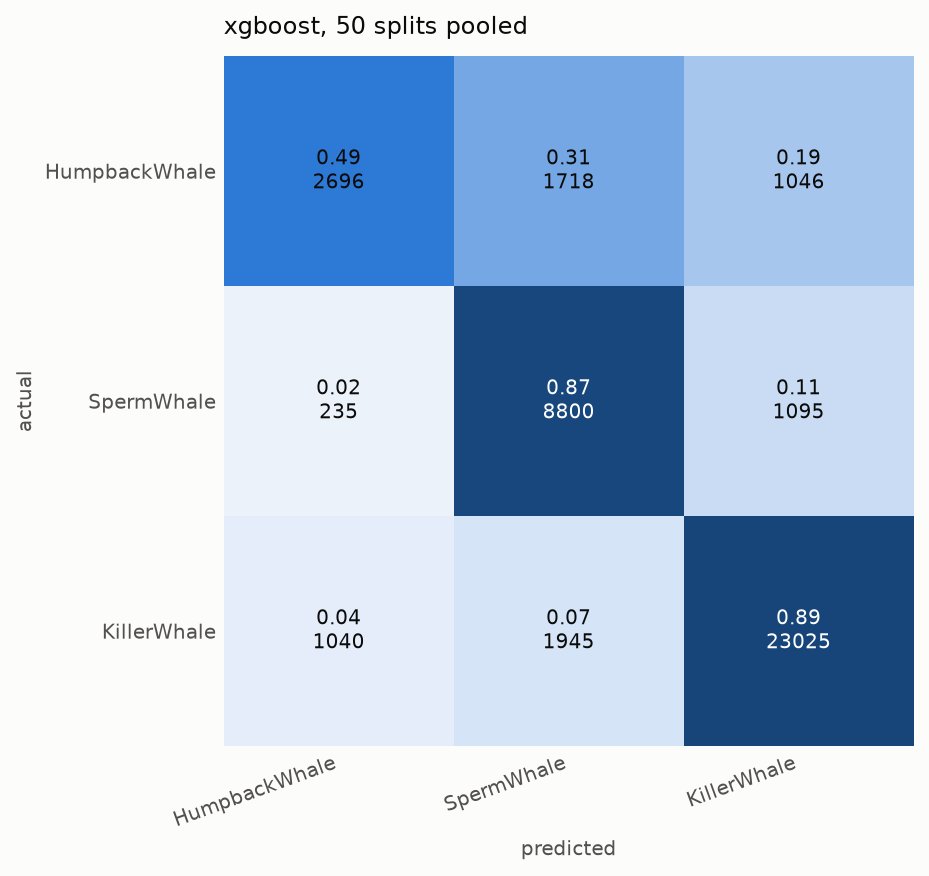

cnn


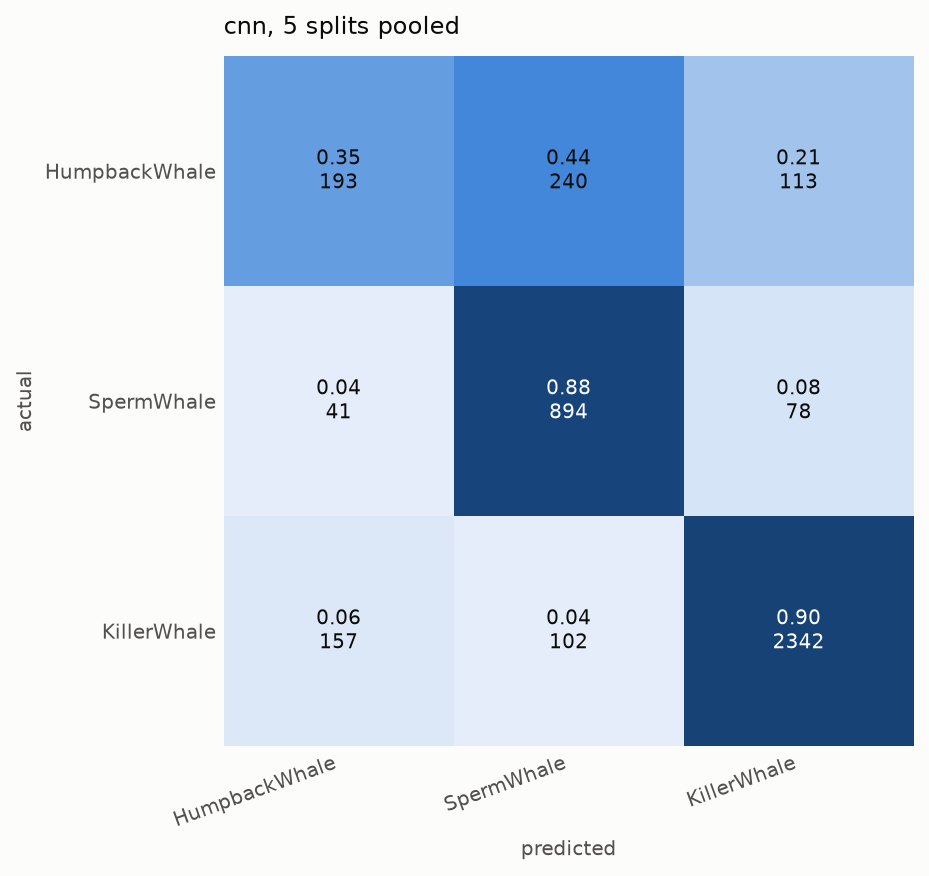

cnn_small


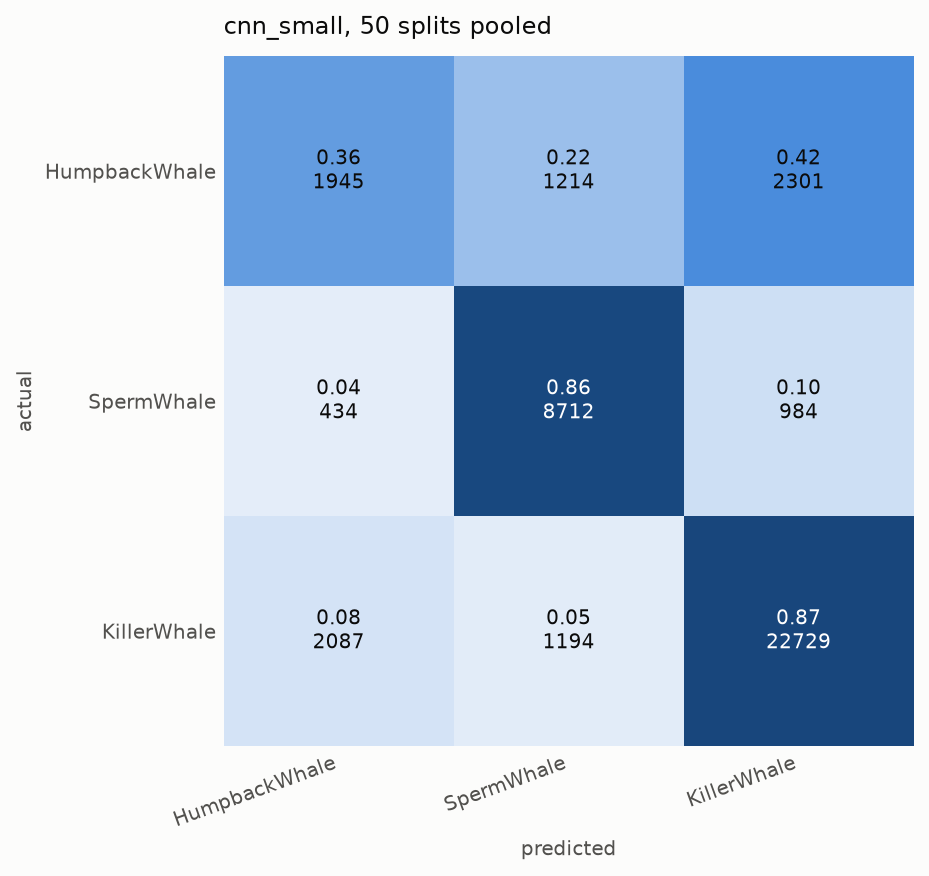

logbook


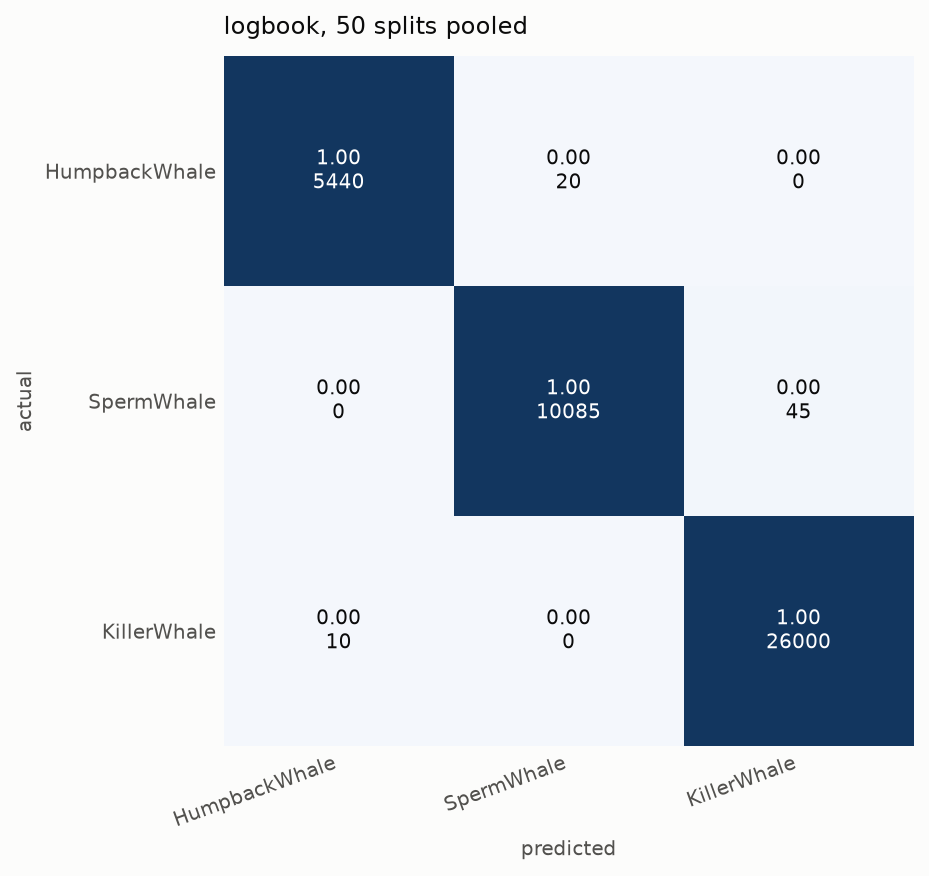

probe


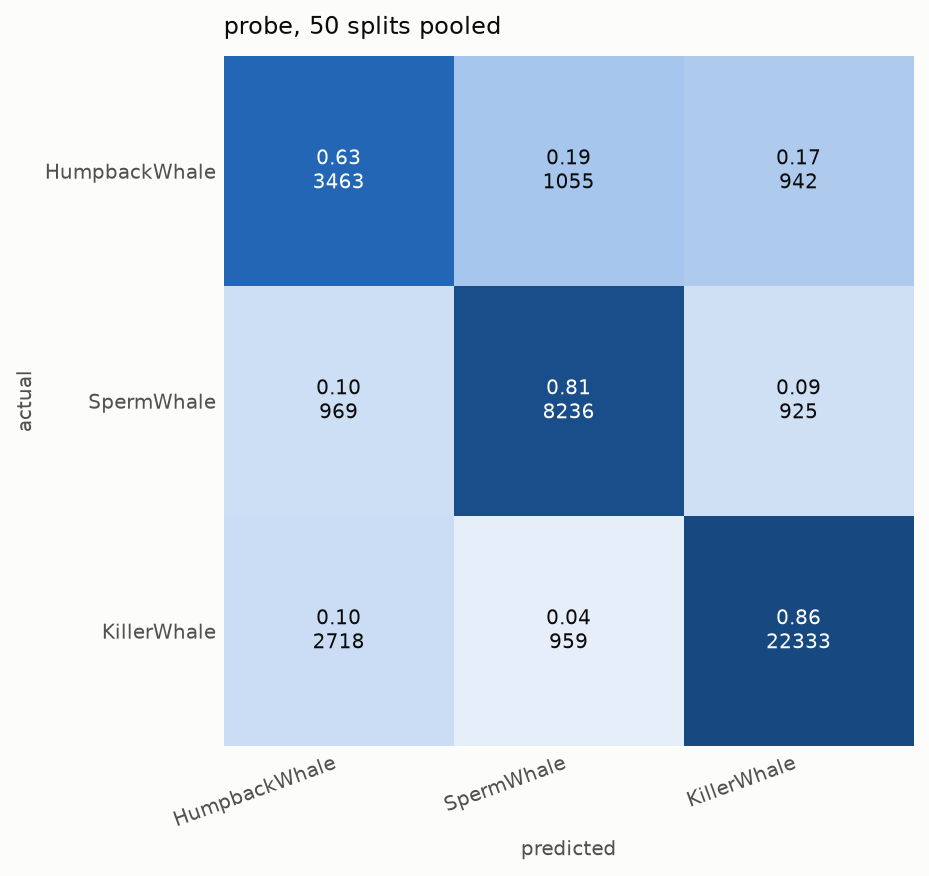

metadata


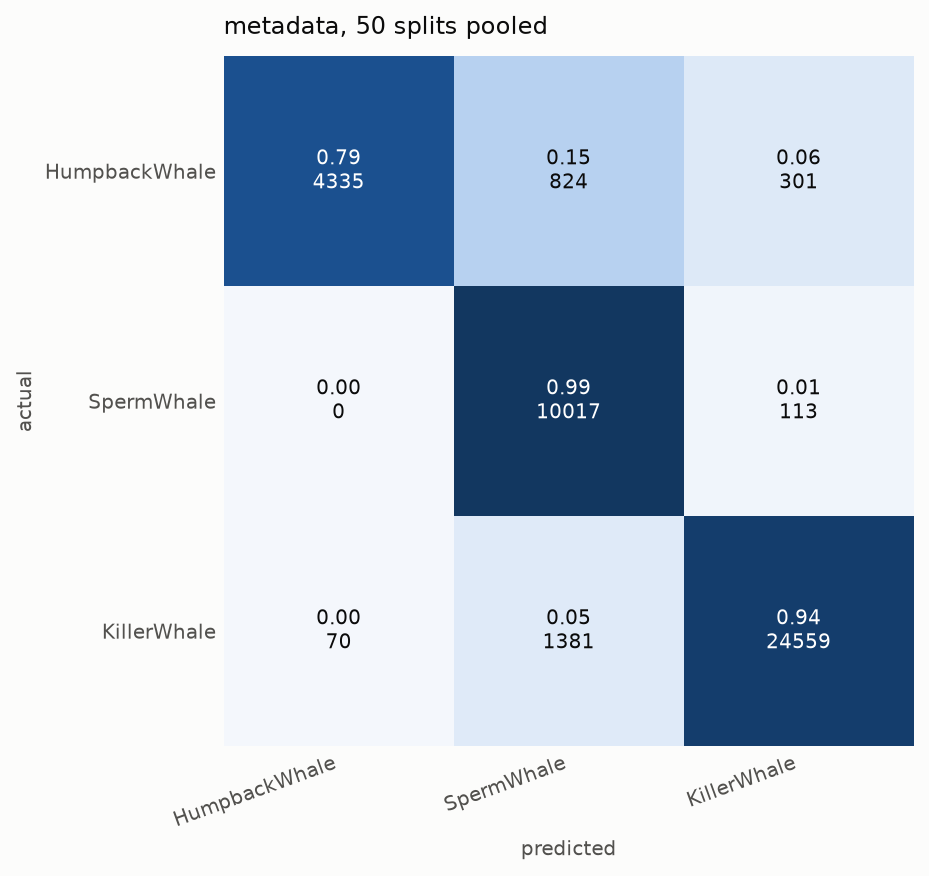

In [11]:
for name in species.names:
    path = REPORT / f"confusion_{name}.png"
    if not path.exists():
        print(f"no confusion figure for {name}")
        continue
    print(name)
    display(Image(filename=str(path)))

## 9. Why the smaller network was the one reported

Both networks were chosen on validation curves alone, with no test fold involved. The larger one
reaches its best validation score within a few epochs on four folds of five and gets worse from
there, which is memorisation of recordings rather than learning of acoustic structure. The smaller
one peaks later and scores better.

cnn        best validation at epochs [14, 16, 2, 6, 20]
cnn_small  best validation at epochs [7, 13, 4, 8, 13]
cnn


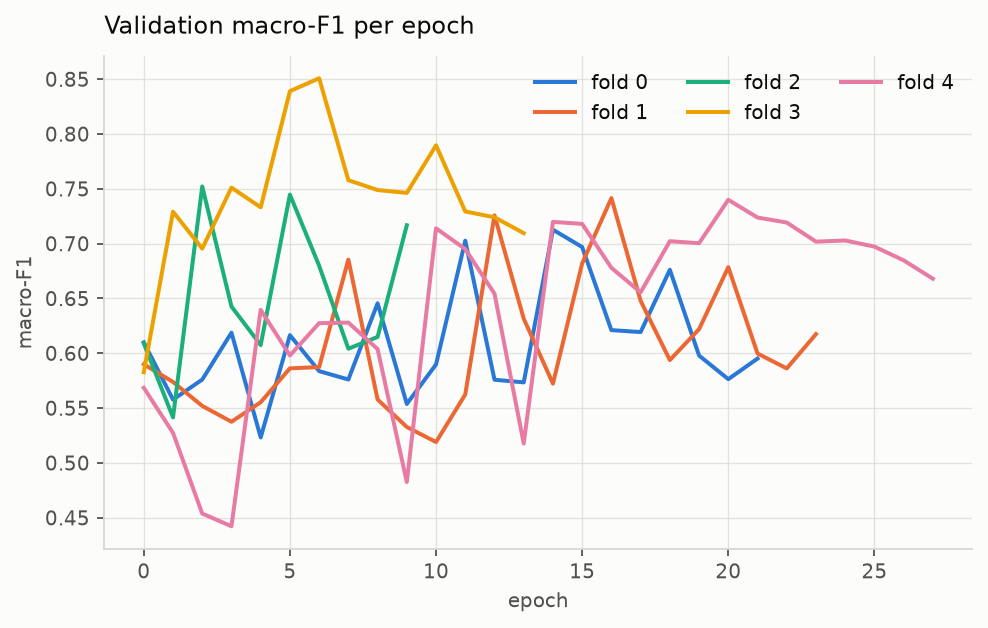

cnn_small


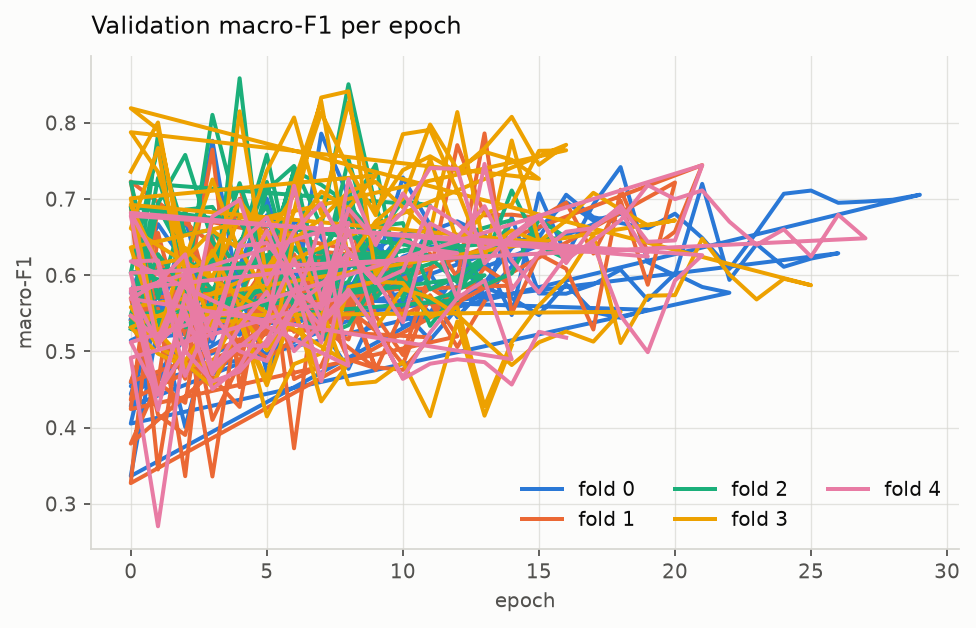

In [12]:
for name in ("cnn", "cnn_small"):
    path = model_directory(cfg, name) / "history.csv"
    if not path.exists():
        continue
    history = pd.read_csv(path)
    peaks = history.loc[history.groupby("fold").val_macro_f1.idxmax()]
    print(f"{name:10s} best validation at epochs {peaks.epoch.tolist()}")

for name in ("cnn", "cnn_small"):
    path = REPORT / f"training_history_{name}.png"
    if path.exists():
        print(name)
        display(Image(filename=str(path)))

## What this notebook does not settle

The two networks carry five estimates each against the trees' fifty, so their comparisons are far
weaker than the tree one even where the point estimate looks similar. The p values in section 5 say
so.

The result is about this corpus. A model that reads the paperwork beats a model that hears the
animal, which is a measurement of how Watkins was assembled rather than a claim about whales.

Notebook 03 addresses the question this one leaves open: fifty estimates are not fifty pieces of
evidence, and the p values above are not the ones an ordinary paired test would give.